# 1) pyGIMLi ERT manager

To start, we want to get to know pyGIMLi's capabilities for ERT data, accessible through in `pygimli.physics.ert`.

This package contains **tools, modelling operators, and managers** for Electrical Resistivity Tomography (ERT) & Induced polarization (IP) data, supplying you with tools to **load, visualize, process and invert** your ERT or IP field data.

The main classes are:

* `DataContainer(ERT)` - ERT/IP-specific data container

* `ERTModelling` - Modelling operator

* `ERTManager` - data inversion and modelling for real resistivity

* `ERTIPManager` - extension to IP (either frequency or time domain)

* `TimelapseERT` - processing and inversion of timelapse ERT data

* `CrossholeERT` - timelapse ERT in crosshole environments

This notebook should provide an **overview of the most basic operations** to help you process your own field data. 
To ensure the learning outcomes, we will provide a data set in case you do not have any own data on hand. 

**But we encourage you to process your own data during this workshop!**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pygimli as pg

from pygimli.physics import ert
import pygimli.meshtools as mt

## 1.1 Data import and sensor position definition

In [2]:
# data = pg.load("../data/AV_multigrad_2.dat")
data = pg.load("../data/AV_DD_2.dat")

coords = np.loadtxt("../data/Coordinates_ERT_P2.txt")

In [3]:
data.sensorPositions()[:5]

[[  0.     0.   299.29]
 [  1.     0.   299.2 ]
 [  2.     0.   299.1 ]
 [  3.     0.   298.98]
 [  4.     0.   298.85]]

In [4]:
data.setSensorPositions(coords) 
data.sensorPositions()[:5]

[[  0.   299.29   0.  ]
 [  1.   299.2    0.  ]
 [  2.   299.1    0.  ]
 [  3.   298.98   0.  ]
 [  4.   298.85   0.  ]]

In [5]:
data.sensorPositions()

R3Vector: n=72

## 1.2 Data container structure and data visualization

In [6]:
data

Data: Sensors: 72 data: 2949, nonzero entries: ['a', 'b', 'i', 'm', 'n', 'r', 'u', 'valid']

In [7]:
data["k"] = ert.createGeometricFactors(data, numerical=True)
data["rhoa"] = data["k"] * data["r"]

15/09/26 - 13:08:08 - pyGIMLi - INFO - Cache c:\Users\Nino Menzel\.venv\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (3.4s x 5): C:\Users\Nino Menzel\AppData\Roaming\pygimli\Cache\4932382573639769785


(<Axes: >, <matplotlib.colorbar.Colorbar at 0x1fd4fb48810>)

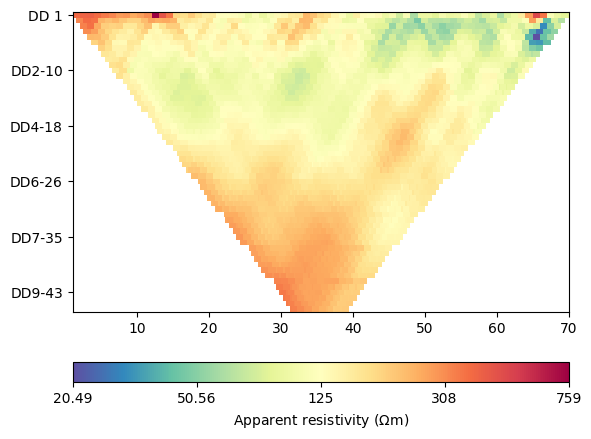

In [8]:
ert.show(data)

## 1.3 Data filtering

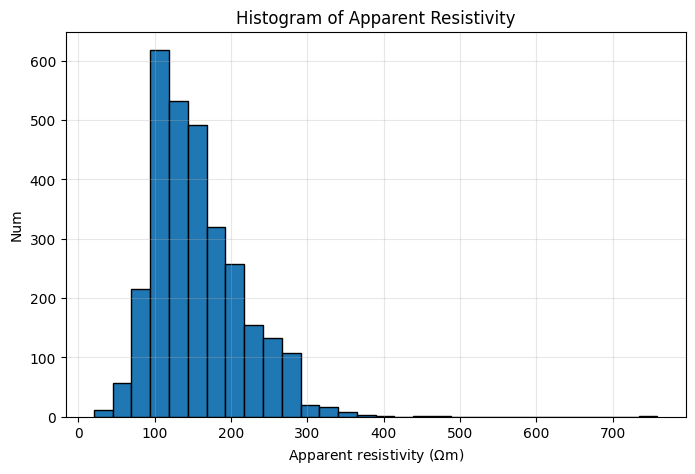

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(np.asarray(data["rhoa"]), bins=30, edgecolor="black")
plt.xlabel(r"Apparent resistivity ($\Omega \text{m}$)")
plt.ylabel("Num")
plt.title("Histogram of Apparent Resistivity")
plt.grid(alpha=0.3)
plt.show()

(<Axes: >, <matplotlib.colorbar.Colorbar at 0x1fd52608190>)

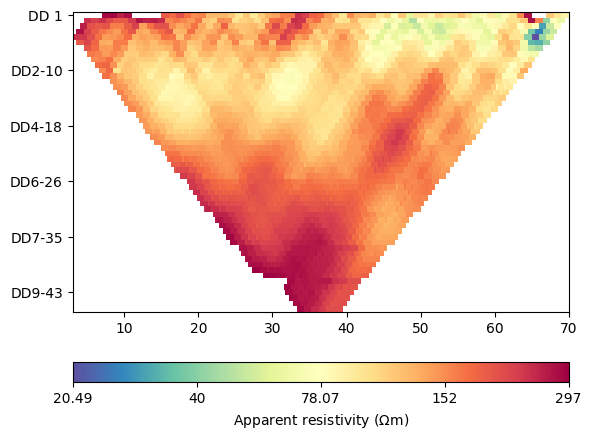

In [10]:
data.remove(data["rhoa"] > 300)
ert.show(data)

In [11]:
# data.removeSensorIdx((67,68))
# ert.show(data)

## 1.4 Error estimation and subsurface discretization

15/09/26 - 13:08:09 - pyGIMLi - INFO - Found 2 regions.
15/09/26 - 13:08:09 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)


Mesh: Nodes: 2901 Cells: 5541 Boundaries: 8441


(<Axes: xlabel='$x$ in m', ylabel='$y$ in m'>, None)

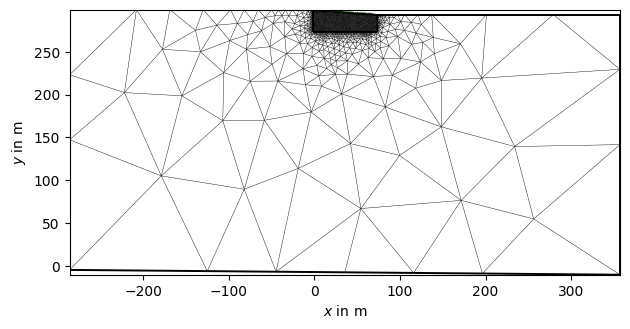

In [12]:
data["err"] = ert.estimateError(data, relativeError=0.0175, absoluteError=0.004)

mgr = ert.ERTManager(data)
plc = mt.createParaMeshPLC(data.sensorPositions(), paraDX=0.33, paraDepth=20, paraMaxCellSize=0.75)

mesh = mt.createMesh(plc)
mgr.setMesh(mesh)
print(mesh)
pg.show(mesh)

## 1.5 First inversion and quality evaluation

In [13]:
invArgs = dict(lam = 45, robustData=False, blockyModel=False, verbose=True)

mgr = ert.ERTManager(data)
inv = mgr.invert(mesh=mesh, **invArgs)

15/09/26 - 13:08:09 - pyGIMLi - INFO - Found 2 regions.
15/09/26 - 13:08:09 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
15/09/26 - 13:08:09 - pyGIMLi - INFO - Creating forward mesh from region infos.
15/09/26 - 13:08:09 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
15/09/26 - 13:08:09 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 11342 Cells: 22164 Boundaries: 16882
15/09/26 - 13:08:09 - pyGIMLi - INFO - Use median(data values)=144.31510713659597
15/09/26 - 13:08:09 - pyGIMLi - INFO - Created startmodel from forward operator:4566, min/max=144.315107/144.315107
15/09/26 - 13:08:09 - pyGIMLi - INFO - Starting inversion.
15/09/26 - 13:08:09 - pyGIMLi - INFO - fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x000001FD597C1AD0>
15/09/26 - 13:08:09 - pyGIMLi - INFO - Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
15/09/26 - 13:08:09 - pyGIMLi - INFO - Model transformation: Logarithm

--------------------------------------------------------------------------------


15/09/26 - 13:08:42 - pyGIMLi - INFO - inv.iter 0 ... chi² =  413.31


--------------------------------------------------------------------------------
inv.iter 1 ... 

15/09/26 - 13:08:51 - pyGIMLi - INFO - chi² =   81.51 (dPhi = 80.00%) lam: 45.0
15/09/26 - 13:09:07 - pyGIMLi - INFO - chi² =    8.38 (dPhi = 87.98%) lam: 45.0


...

--------------------------------------------------------------------------------
inv.iter 4 ... 

15/09/26 - 13:09:39 - pyGIMLi - INFO - chi² =    1.06 (dPhi = 18.75%) lam: 45.0


--------------------------------------------------------------------------------
inv.iter 5 ... 

15/09/26 - 13:09:57 - pyGIMLi - INFO - chi² =    0.98 (dPhi = 3.01%) lam: 45.0




################################################################################
#                  Abort criterion reached: chi² <= 1 (0.98)                   #
################################################################################


(<Axes: xlabel='$x$ in m', ylabel='$y$ in m'>,
 <matplotlib.colorbar.Colorbar at 0x1fd595c3b50>)

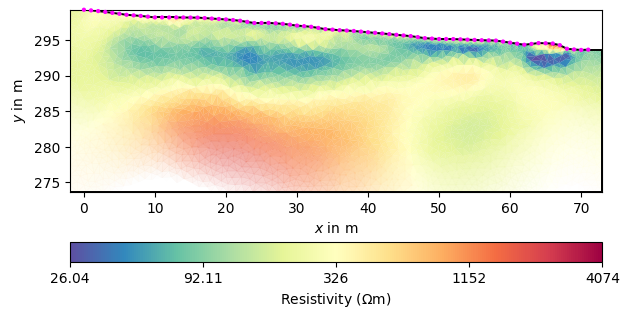

In [14]:
mgr.showResult()

In [15]:
# mgr.inv.relrms()

# mgr.inv.chi2()

c:\Users\Nino Menzel\.venv\Lib\site-packages\pygimli\viewer\mpl\utils.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  ax.figure.tight_layout()


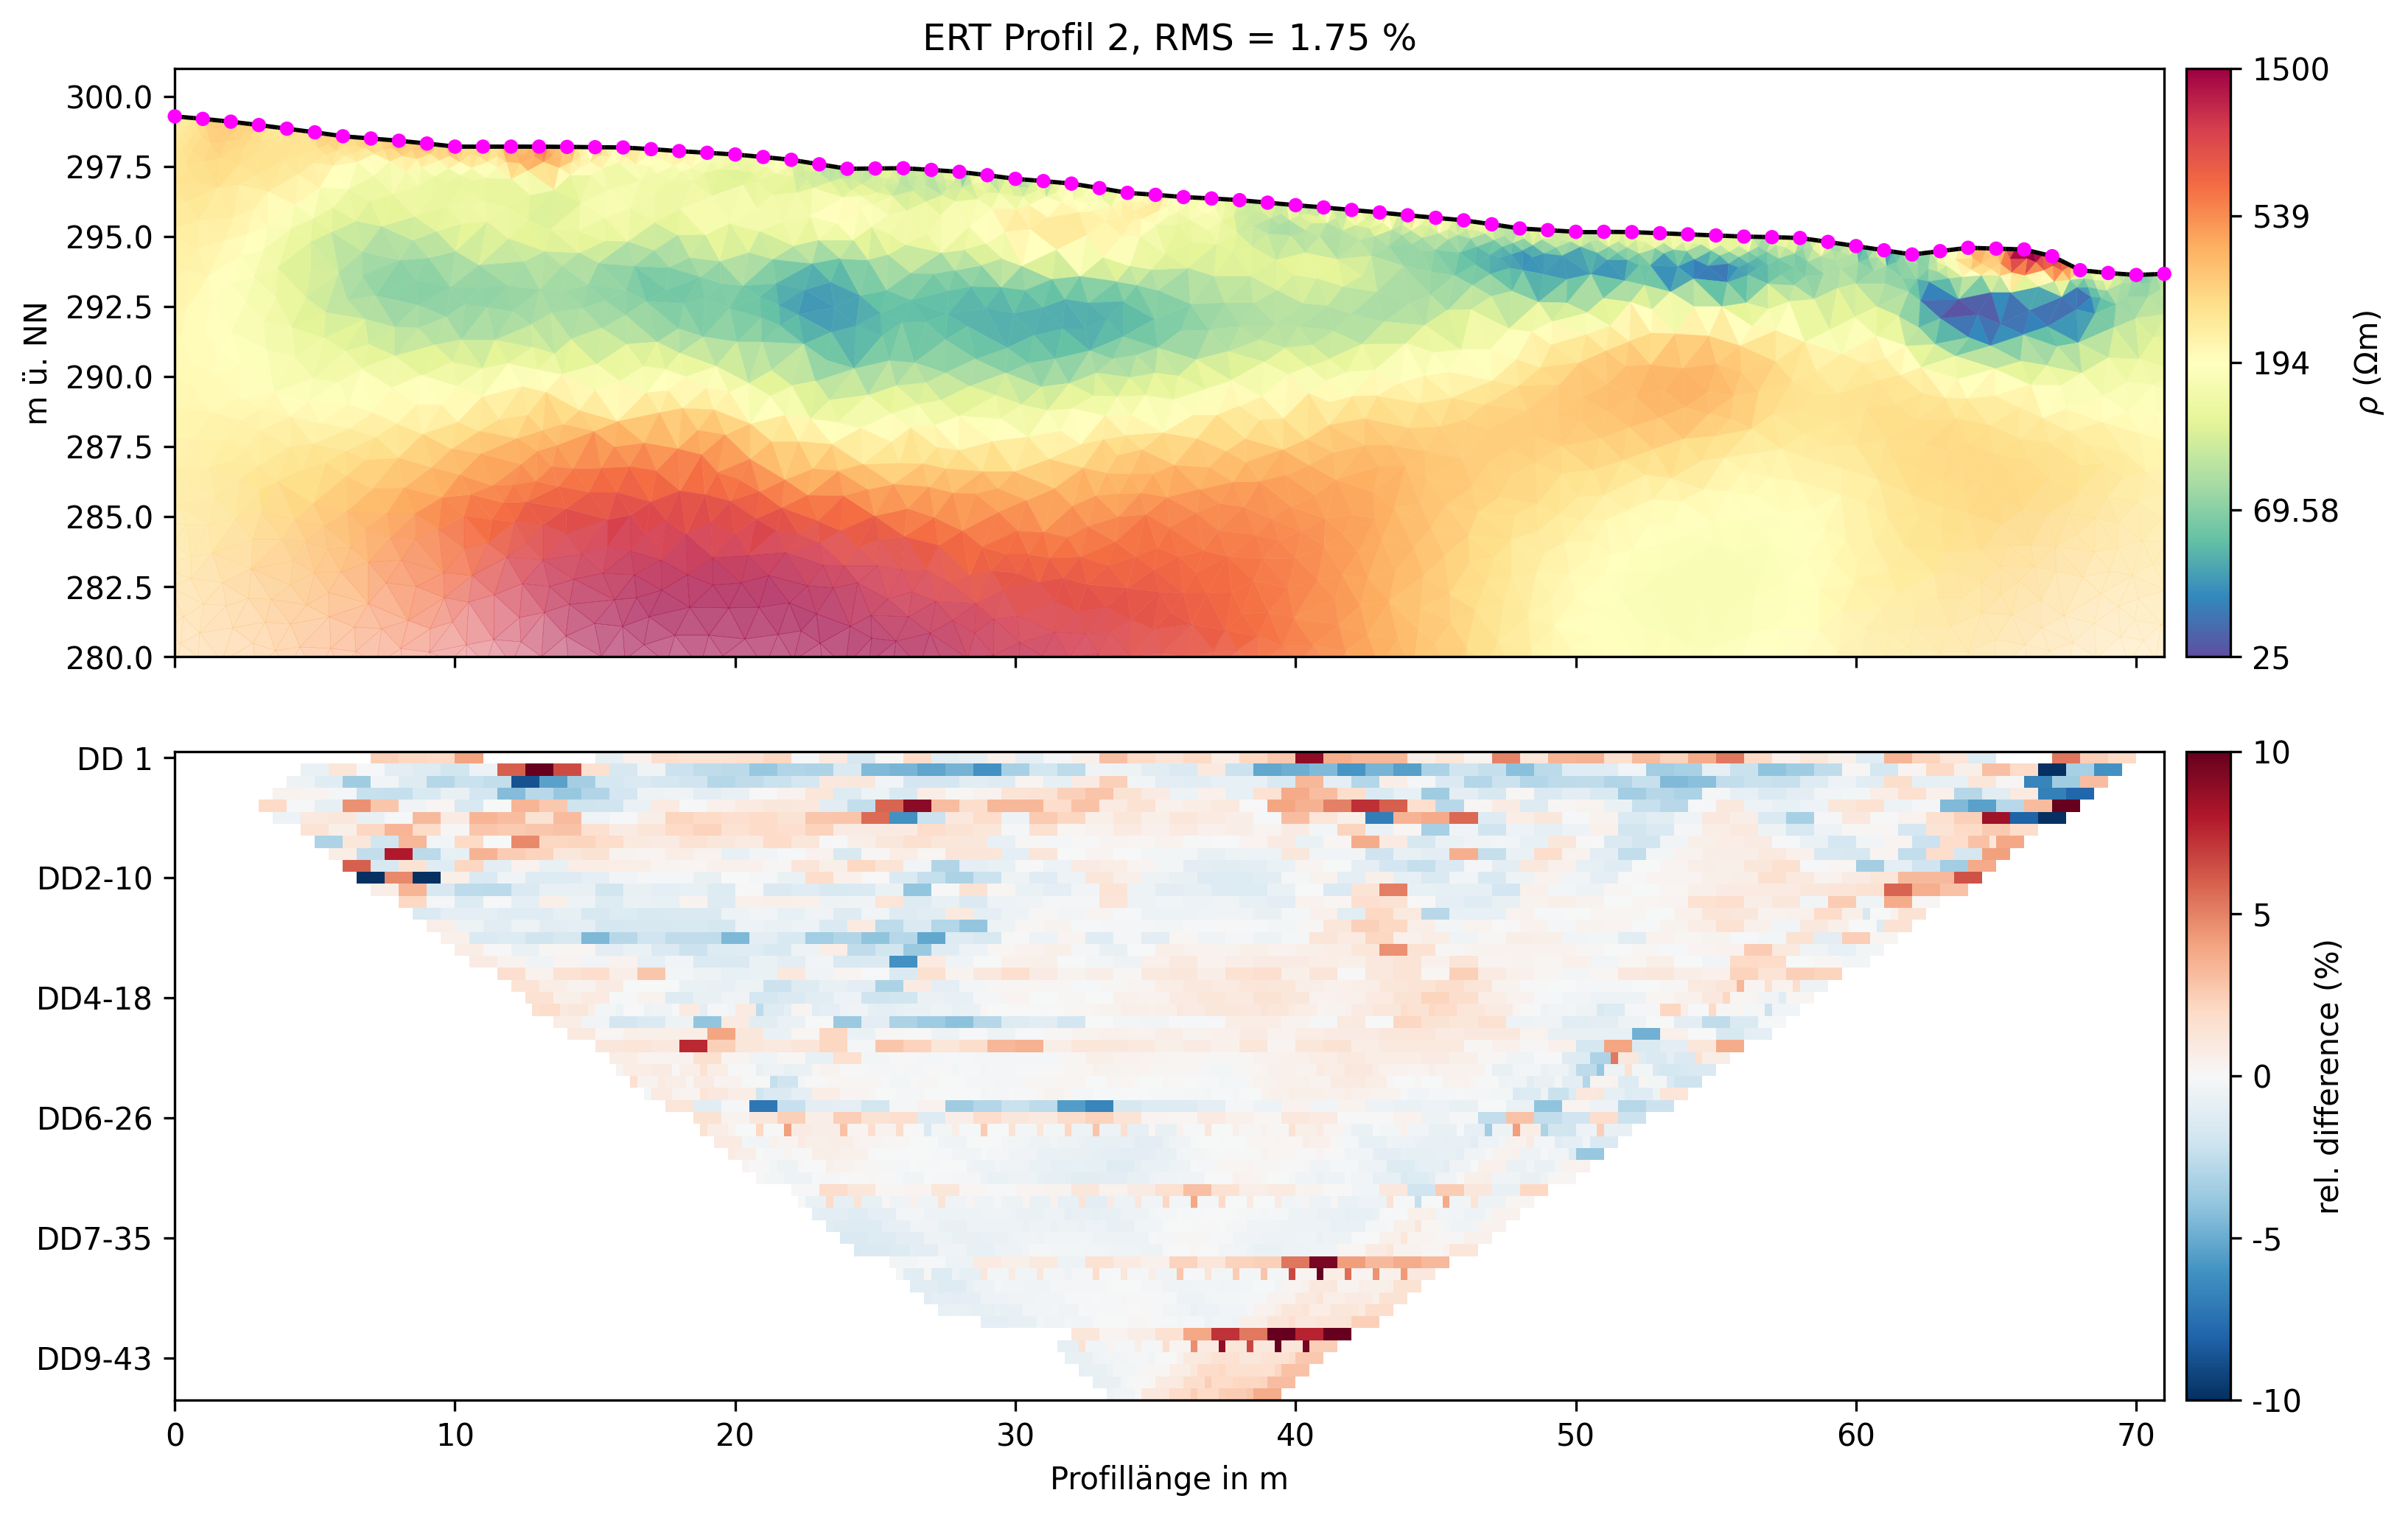

In [16]:
rKW = dict(logScale=True, cMin=25, cMax=1500, 
           coverage = mgr.coverage(), orientation="vertical", 
           showTopo = True, label = r"$\rho$ ($\Omega$m)")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), dpi=300, sharex=True, gridspec_kw={'hspace': .1})

mgr.showResult(ax=ax1, **rKW)
ax1.axis()
ax1.set_ylim(280, 301)
ax1.set_xlim(0, 71)
ax1.set_ylabel("m ü. NN")
ax1.set_title(f"ERT Profil 2, RMS = {mgr.inv.relrms():.2f} %")
ax1.set_xlabel("")
ax1.set_aspect("equal")

diff = (data['rhoa'] - mgr.inv.response)/mgr.inv.response * 100
ert.show(data, ax=ax2, vals=diff, cMin = -10, cMax = 10, orientation = "vertical", cMap = "RdBu_r", label = "rel. difference (%)")
ax2.set_xlabel("Profillänge in m")
ax2.set_xlim(0,71)
ax2.set_aspect("auto")

## 1.6 Save your data and mesh

In [ ]:
np.savetxt("../data/coverage_ERT.txt", mgr.coverage())
m = pg.Mesh(mgr.paraDomain)
m['Resistivity'] = mgr.paraModel(mgr.model)
m.exportVTK(f'../data/inv_ERT')